# ***Name : Banibrata Manna*** 
# ***Department : IEOR***
# ***Roll : 25M1520***
# ***Course : EE769***
---

# **Import Necessary Modules**

In [1]:
import time
start = time.time()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Decomposition & Feature Selection
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Regression models
from sklearn.linear_model import ElasticNet
from sklearn.svm import LinearSVR, SVR
from sklearn.tree import DecisionTreeRegressor

# Metrics (classification + regression)
from sklearn.metrics import (
    classification_report,
    roc_curve, auc,
    f1_score,
    accuracy_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [4]:
from mord import LogisticIT

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# **(1) Credit Card Default Prediction**

#### *Predict whether a customer will default on credit card payments.*

In [6]:
df = pd.read_excel("Credit_Card.xls", skiprows=1)
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns=["ID"], inplace=True)   # drop ID column
df.rename(columns={"default payment next month": "Default"}, inplace=True)  # rename target column

---

## {1.1} **Explore the data** 

#### *Note down your observations about the problem type, variable types, missing variables, distributions, correlations, and label distribution. Are there any strong associations between any input and output variable that are immediately obvious? What performance metrics should be used and why?*

## {1.1.1} **Problem Type** :
This is a ***supervised binary classification problem.*** <br>
default = 1 → customer defaults <br>
default = 0 → customer does not default

## {1.1.2} **Variable Types** :

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

Actually all potential categorical features are encoded to integer.
For example : <br>
**"SEX"** is label encoded to 1 (male) and 2 (female). <br>
**"MARRIAGE"** is label encoded to 0 to 3. <br>
**"EDUCATION"** is ordinal encoded to 0 to 6.

Rest are numerical features.

In [10]:
df["SEX"].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

In [11]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [12]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

## {1.1.3} **Missing Variables** :

In [13]:
df.isnull().sum()

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
Default      0
dtype: int64

**The dataset has no missing values as well as no duplicated rows.**

## {1.1.4} **Distribution** :

In [14]:
def plot_histograms(df, title):
    n_cols = 5
    n_rows = int(np.ceil(len(df.columns) / n_cols)) # variable no. of rows

    plt.figure(figsize=(15, 3*n_rows))
    
    for i, col in enumerate(df.columns):
        plt.subplot(n_rows, n_cols, i+1)
        sns.histplot(df[col], bins=30, color="green", alpha=0.6, stat="density")
        sns.kdeplot(df[col], color="purple", linewidth=2)
        plt.title(col)
    
    plt.suptitle(f"{title}\n(25M1520)\n", fontsize=13)
    plt.tight_layout(rect=[0,0,1,1])
    plt.show()

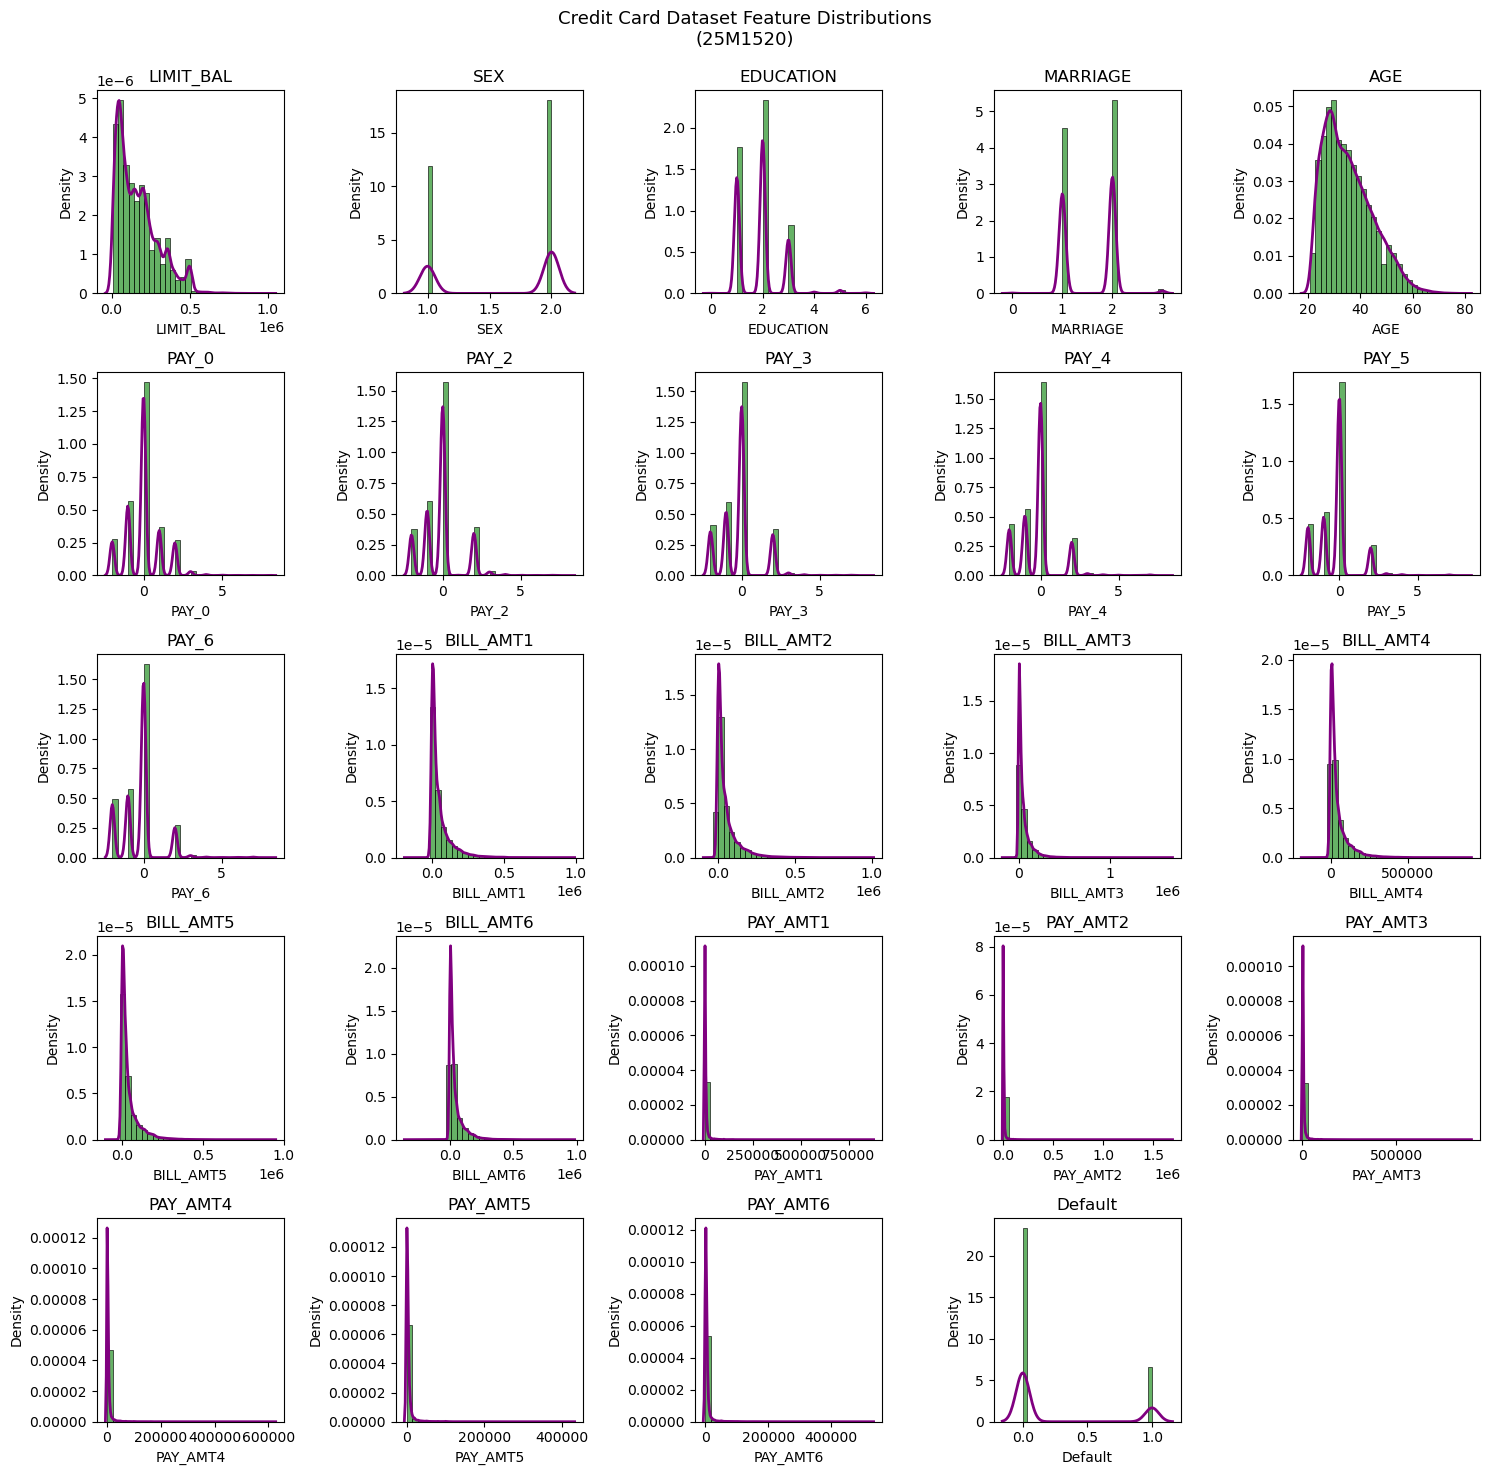

In [15]:
plot_histograms(df, "Credit Card Dataset Feature Distributions")

## {1.1.5} **Correlation** :

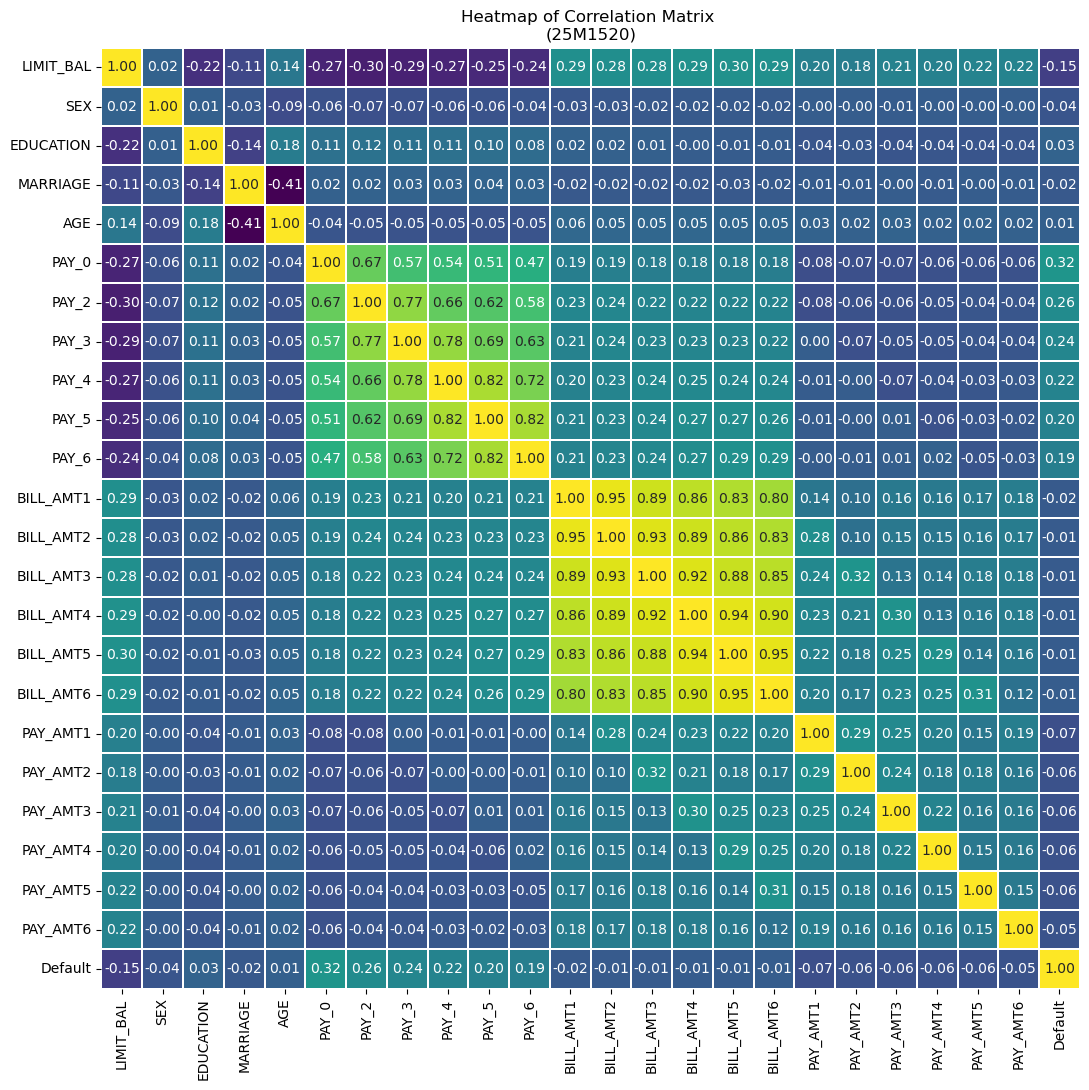

In [16]:
plt.figure(figsize=(11,11))
sns.heatmap(df.corr(), cmap="viridis", annot=True, linewidths=0.1, fmt=".2f", cbar=False)
plt.title("Heatmap of Correlation Matrix \n(25M1520)")
plt.tight_layout()
plt.show()

## {1.1.6} **Label Distribution** :

In [17]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [18]:
y.value_counts()

Default
0    23364
1     6636
Name: count, dtype: int64

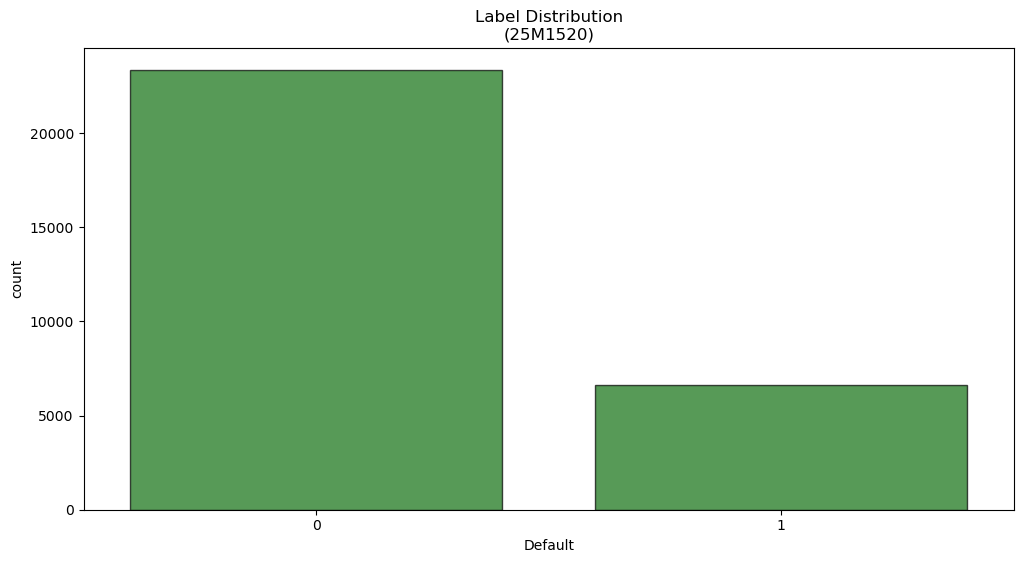

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(x=y, color='green', alpha=0.7, edgecolor='black')
plt.title('Label Distribution\n(25M1520)')
plt.show()

In [20]:
print(f"Out of {df.shape[0]} people {np.mean(y==0)*100:.2f}% are non-defaulters")
print(f"Out of {df.shape[0]} people {np.mean(y==1)*100:.2f}% are defaulters")

Out of 30000 people 77.88% are non-defaulters
Out of 30000 people 22.12% are defaulters


The dataset is **moderately imbalanced** with approximately **78%** non-default and **22%** default cases, accuracy alone may be misleading. <br>

Therefore, evaluation metrics such as **precision**, **recall**, **F1-score** and **ROC-AUC** should be used. <br>

* **Precision** measures how many predicted defaulters are actually defaulters.
* **Recall** measures how many actual defaulters are detected.
* **F1-score** balances both precision and recall.
*  **ROC-AUC** evaluates the model’s ability to distinguish between default and non-default customers across different thresholds.

In [21]:
corr = df.corr(numeric_only=True)
corr['Default'].sort_values(ascending=False)

Default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: Default, dtype: float64

* **Positive correlation:** Repayment status variables (**PAY_0–PAY_6**) show the strongest positive association with default. Higher payment delays correspond to a higher probability of default.

* **Negative correlation:** **LIMIT_BAL** and payment amount variables (**PAY_AMT1–PAY_AMT6**) show negative correlations, meaning customers with higher credit limits and larger payments are less likely to default.

---

## {1.2} **Data transformations**

#### *Perform appropriate data transformations and data reduction.*

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1520)

## {1.2.1} **Feature Scaling** :

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## {1.2.2} **Feature Reduction** :

In [24]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

---

## {1.3} **ML model type**

#### *Compare logistic regression, simple SVM, RBF kernel SVM, and decision tree, each with hyperparameter tuning. Depending on the inputs and EDA, which of these were likely to work better depending on input variables and their association with the output variable? Did the observations meet your expectations?*

## {1.3.1} **Model Building** :

In [25]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {"C":[0.01,0.1,1,10]}
    ),
    
    "Simple SVM": (
        LinearSVC(),
        {"C":[0.1,1,10]}
    ),
    
    "RBF SVM": (
        SVC(kernel="rbf"),
        {"C":[0.1,1,10], "gamma":[0.01,0.1,1]}
    ),
    
    "Decision Tree": (
        DecisionTreeClassifier(),
        {"max_depth":[3,5,10,None], "min_samples_split":[2,5,10]}
    )
}

In [26]:
for name, (model, params) in models.items():
    
    grid = GridSearchCV(model, params, cv=5, scoring="f1")
    grid.fit(X_train_pca, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_pca)
    
    print(name)
    print("Best Params:", grid.best_params_)
    print(classification_report(y_test, y_pred))
    print("--"*27)

Logistic Regression
Best Params: {'C': 1}
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      4641
           1       0.71      0.16      0.27      1359

    accuracy                           0.80      6000
   macro avg       0.76      0.57      0.57      6000
weighted avg       0.78      0.80      0.74      6000

------------------------------------------------------
Simple SVM
Best Params: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      4641
           1       0.74      0.10      0.17      1359

    accuracy                           0.79      6000
   macro avg       0.77      0.54      0.53      6000
weighted avg       0.78      0.79      0.72      6000

------------------------------------------------------
RBF SVM
Best Params: {'C': 10, 'gamma': 0.1}
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      4641
     

## {1.3.2} **Model Comparison** :

Four models were evaluated: **Logistic Regression**, **Simple SVM**, **RBF kernel SVM** and **Decision Tree**, with hyperparameter tuning performed using cross-validation to identify the best configurations.

All three models achieved a similar overall accuracy of ***around 78-80%***, which is largely driven by the class imbalance in the dataset (majority class dominates). Therefore, performance on the minority class (class 1) is more informative for comparison.

### **1. Logistic Regression:** 
It performed strongly on the majority class but struggled with the minority class, achieving a ***precision*** of ***0.71***, ***recall*** of ***0.16*** and an ***F1-score*** of ***0.27*** for class 1. This suggests that while predictions of class 1 are relatively reliable, the model fails to capture most actual positives. This behavior aligns with expectations when relationships are weakly linear or when classes are imbalanced.

### **2. Simple SVM (Linear SVM):** 
It showed similar behavior, with a ***precision*** of ***0.74***, ***recall*** of ***0.10*** and an ***F1-score*** of ***0.17*** for class 1. Despite slightly higher precision, its extremely low recall indicates that the linear decision boundary is too restrictive, missing most minority instances. This is expected if the true decision boundary is not linearly separable.

### **3. RBF kernel SVM:** 
It significantly improved minority class detection, achieving a ***precision*** of ***0.65***, ***recall*** of ***0.28*** and an ***F1-score*** of ***0.39***. This indicates a much better balance between identifying positives and controlling false positives. This improvement suggests the presence of non-linear relationships in the data, which the RBF kernel is able to capture effectively.

### **4. Decision Tree:** 
It produced a ***precision*** of ***0.53***, ***recall*** of ***0.32*** and an ***F1-score*** of ***0.40*** for class 1. It achieved the highest recall among all models, indicating that it captures more actual positives. This suggests that there are threshold-based or rule-like patterns in the data. However, its lower precision indicates more false positives compared to RBF SVM.

Overall, the observations largely meet expectations based on EDA. If the input variables exhibit non-linear interactions or threshold effects, models like **RBF SVM** and **Decision Trees** are expected to outperform linear models. In this case, both non-linear models indeed perform better on the minority class. Among them, the Decision Tree slightly edges out in recall and F1-score, while the RBF kernel SVM provides a better precision–recall balance.

## {1.3.3} **Conclusion** :

From the **exploratory data analysis**, repayment status variables (PAY_0–PAY_6) showed the strongest association with the target variable. These variables may create nonlinear relationships with the probability of default. Therefore, models capable of capturing nonlinear patterns, such as RBF SVM and Decision Trees, were expected to perform better than linear models.

The experimental results were consistent with this expectation. Both **RBF Kernel SVM** and **Decision Tree** improved the identification of defaulters compared to **Logistic Regression**, indicating that nonlinear models are more suitable for this prediction problem.

---

## {1.4} **Importance of data transformations** 

#### *Compare using data with and without scaling in logistic regression versus decision tree.*

We have trained models with data transformations. To do the same without data transformation we must pass X_train to then models.

In [27]:
import warnings

# Suppress Python warnings
warnings.filterwarnings("ignore")

In [28]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {"C":[0.01,0.1,1,10]}
    ),
    
    "Decision Tree": (
        DecisionTreeClassifier(),
        {"max_depth":[3,5,10,None], "min_samples_split":[2,5,10]}
    )
}

In [29]:
for name, (model, params) in models.items():
    
    grid = GridSearchCV(model, params, cv=5, scoring="f1")
    grid.fit(X_train, y_train)              # X_train instead of X_train_pca
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)     # X_test instead of X_test_pca
    
    print(name)
    print("Best Params:", grid.best_params_)
    print(classification_report(y_test, y_pred))
    print("--"*27)

Logistic Regression
Best Params: {'C': 10}
              precision    recall  f1-score   support

           0       0.80      0.97      0.88      4641
           1       0.67      0.18      0.29      1359

    accuracy                           0.79      6000
   macro avg       0.73      0.58      0.58      6000
weighted avg       0.77      0.79      0.75      6000

------------------------------------------------------
Decision Tree
Best Params: {'max_depth': 3, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4641
           1       0.69      0.35      0.47      1359

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.79      6000

------------------------------------------------------


A comparison was conducted between models trained on **scaled** and **unscaled data** for **Logistic Regression** and **Decision Tree**, to understand the impact of feature scaling on performance.

Overall, scaling had noticeable effects on **Logistic Regression**, while **Decision Tree** remained largely unaffected, which aligns with theoretical expectations.

### Model Comparisons (Class 1) :

#### **Logistic Regression (With vs. Without Scaling)**

* With Scaling: ***Recall*** of ***0.16***, ***F1-score*** of ***0.27***.

* Without Scaling: ***Recall*** of ***0.18***, ***F1-score*** of ***0.29***.

#### **Analysis:**
*This indicates a minor improvement without scaling, which is somewhat unexpected since Logistic Regression typically benefits from scaling. However, this suggests that the original feature magnitudes may already be reasonably comparable or that scaling slightly distorted feature importance. In general, Logistic Regression is sensitive to feature scales, but in this case, the impact was limited.*

#### **Decision Tree (With vs. Without Scaling)**

* With Scaling: ***Recall*** of ***0.32***, ***F1-score*** of ***0.40***.

* Without Scaling: ***Recall*** of ***0.35***, ***F1-score*** of ***0.47***.

#### **Analysis:** 
*The Decision Tree showed very similar behavior across both settings, with performance improving slightly without scaling. This is expected because Decision Trees are scale-invariant, as they rely on feature splits rather than distance or magnitude.*

---

## {1.5} **Stability of model comparison**

#### *Compare the best and the worst model type with different train-val-test splits to check the stability of their relative performance.*

### *Best Model : Decision Tree with max_depth=10, min_samples_split=2*
### *Worst Model : Linear SVC with C=0.1*


Test Size = 0.2
------------------------------------------------------
Decision Tree Classifier (Best Model)
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      4641
           1       0.53      0.32      0.40      1359

    accuracy                           0.78      6000
   macro avg       0.67      0.62      0.63      6000
weighted avg       0.75      0.78      0.76      6000

------------------------------------------------------
Linear SVC
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      4641
           1       0.74      0.10      0.17      1359

    accuracy                           0.79      6000
   macro avg       0.77      0.54      0.53      6000
weighted avg       0.78      0.79      0.72      6000

------------------------------------------------------


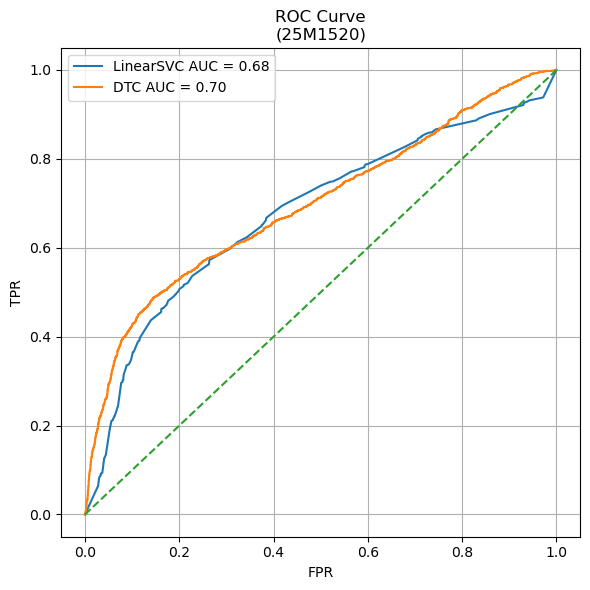


Test Size = 0.25
------------------------------------------------------
Decision Tree Classifier (Best Model)
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      5800
           1       0.53      0.32      0.40      1700

    accuracy                           0.78      7500
   macro avg       0.68      0.62      0.63      7500
weighted avg       0.76      0.78      0.76      7500

------------------------------------------------------
Linear SVC
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      5800
           1       0.71      0.09      0.16      1700

    accuracy                           0.79      7500
   macro avg       0.75      0.54      0.52      7500
weighted avg       0.77      0.79      0.72      7500

------------------------------------------------------


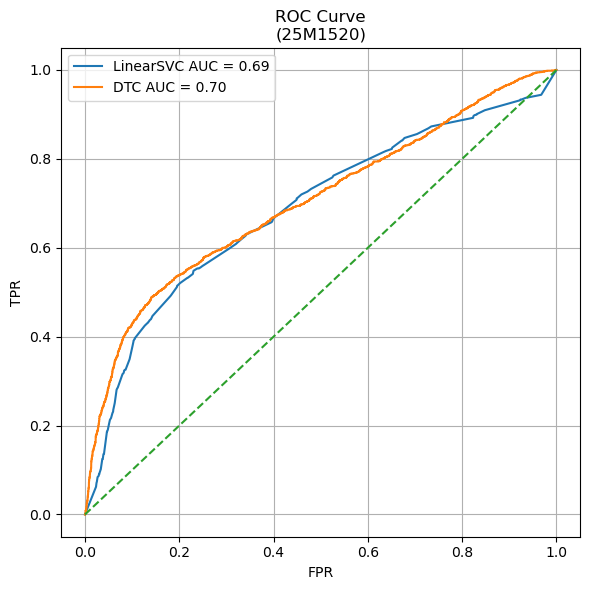


Test Size = 0.3
------------------------------------------------------
Decision Tree Classifier (Best Model)
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      6969
           1       0.53      0.30      0.39      2031

    accuracy                           0.78      9000
   macro avg       0.68      0.61      0.63      9000
weighted avg       0.75      0.78      0.76      9000

------------------------------------------------------
Linear SVC
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      6969
           1       0.72      0.09      0.16      2031

    accuracy                           0.79      9000
   macro avg       0.75      0.54      0.52      9000
weighted avg       0.77      0.79      0.72      9000

------------------------------------------------------


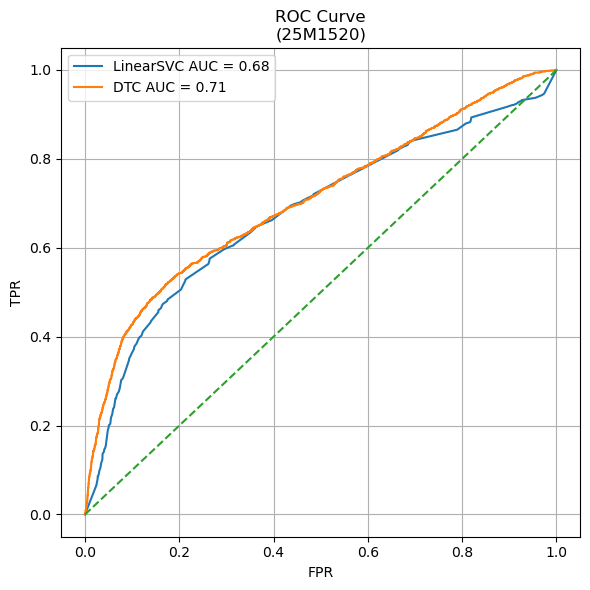


Test Size = 0.35
------------------------------------------------------
Decision Tree Classifier (Best Model)
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      8143
           1       0.56      0.31      0.40      2357

    accuracy                           0.79     10500
   macro avg       0.69      0.62      0.64     10500
weighted avg       0.76      0.79      0.77     10500

------------------------------------------------------
Linear SVC
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      8143
           1       0.71      0.09      0.17      2357

    accuracy                           0.79     10500
   macro avg       0.75      0.54      0.52     10500
weighted avg       0.77      0.79      0.72     10500

------------------------------------------------------


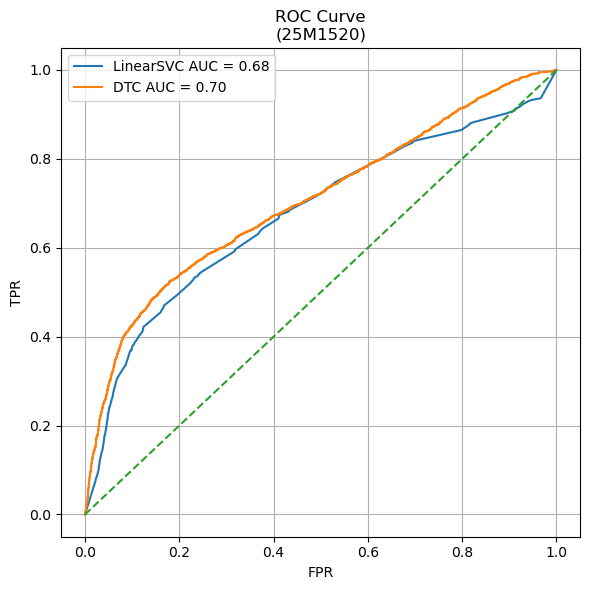


Test Size = 0.4
------------------------------------------------------
Decision Tree Classifier (Best Model)
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      9274
           1       0.54      0.29      0.38      2726

    accuracy                           0.78     12000
   macro avg       0.68      0.61      0.62     12000
weighted avg       0.75      0.78      0.76     12000

------------------------------------------------------
Linear SVC
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      9274
           1       0.72      0.09      0.17      2726

    accuracy                           0.79     12000
   macro avg       0.75      0.54      0.52     12000
weighted avg       0.77      0.79      0.72     12000

------------------------------------------------------


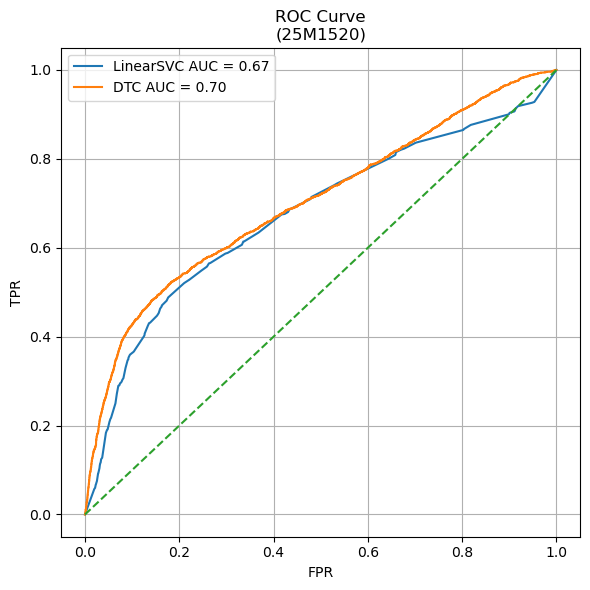

In [30]:
test_sizes = [0.2, 0.25, 0.3, 0.35, 0.4]

for ts in test_sizes:
    print(f"\nTest Size = {ts}")
    print("--"*27)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=1520)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=10)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # --- Decision Tree Classifier ---
    dtc = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=1520)
    dtc.fit(X_train_pca, y_train)
    y_pred_dtc = dtc.predict(X_test_pca)

    print("Decision Tree Classifier (Best Model)")
    print(classification_report(y_test, y_pred_dtc))
    print("--"*27)

    # --- Linear Support Vector Classifier ---
    svc = LinearSVC(C=0.1)
    svc.fit(X_train_pca, y_train)
    y_pred_svc = svc.predict(X_test_pca)

    print("Linear SVC")
    print(classification_report(y_test, y_pred_svc))
    print("--"*27)
    
    # Compute ROC for both models for each test size
    fpr1, tpr1, _ = roc_curve(y_test, dtc.predict_proba(X_test_pca)[:, 1])
    fpr2, tpr2, _ = roc_curve(y_test, svc.decision_function(X_test_pca))
    roc_auc1 = auc(fpr1, tpr1)
    roc_auc2 = auc(fpr2, tpr2)

    # Plot
    plt.figure(figsize=(6,6))
    plt.plot(fpr1, tpr1, label=f'LinearSVC AUC = {roc_auc1:.2f}')
    plt.plot(fpr2, tpr2, label=f'DTC AUC = {roc_auc2:.2f}')
    plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line

    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve\n(25M1520)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("=="*38) 

**The superior AUC of the Decision Tree Classifier indicates the presence of nonlinear relationships in the feature space, which are not captured by the linear decision boundary of Linear SVC.**

---

## {1.6} **Recursive feature elimination**

#### *For the best model, if you perform recursive feature elimination, then does it lead to better results with a smaller set of features? Can you make any observations about features retained or eliminated?*

### *Best Model : Decision Tree with max_depth=10, min_samples_split=2*

**as feature selection should be done recursively we have to perform operations with X_train_scaled and X_test_scaled instead of X_train_pca and X_test_pca**

In [31]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [32]:
# Baseline: Best Model (All Features)
best_model = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=1520)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

print("All Features:", list(X_train_scaled.columns))
print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

All Features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      9274
           1       0.61      0.39      0.48      2726

    accuracy                           0.81     12000
   macro avg       0.73      0.66      0.68     12000
weighted avg       0.79      0.81      0.79     12000

F1 Score: 0.4753987867894855


In [33]:
# RFE using Decision Tree
selector = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=1520)

rfe = RFE(selector, n_features_to_select=2)   # keep small like your example
rfe.fit(X_train_scaled, y_train)

# selected features
cols = list(X_train_scaled.columns[rfe.support_])

# Retrain Decision Tree on selected features
model = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=1520)
model.fit(X_train_scaled[cols], y_train)
y_pred = model.predict(X_test_scaled[cols])

print("Selected:", cols)
print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Selected: ['PAY_0', 'BILL_AMT1']
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      9274
           1       0.70      0.31      0.43      2726

    accuracy                           0.81     12000
   macro avg       0.76      0.64      0.66     12000
weighted avg       0.80      0.81      0.78     12000

F1 Score: 0.43240506329113926


## **Verdict** :

For the best-performing **Decision Tree (max_depth = 10, min_samples_split = 2)**, Recursive Feature Elimination (RFE) was applied to evaluate whether a reduced subset of features could improve model performance.

The model trained on all features achieved an ***F1-score*** of ***0.475*** for the minority class. After applying RFE and selecting only two features (`PAY_0` and `BILL_AMT1`), the performance decreased to an ***F1-score*** of ***0.432***. Additionally, ***recall*** dropped from ***0.39*** to ***0.31***, indicating that the model became less effective at identifying defaulters.

The selected features—`PAY_0` (recent repayment status) and `BILL_AMT1` (most recent bill amount)—are intuitively strong predictors and align with earlier observations from EDA, suggesting that recent repayment behavior and current financial exposure are highly influential in determining default risk.

However, the decline in performance after feature reduction indicates that the Decision Tree benefits from a broader set of features. Variables such as historical repayment status (`PAY_2`–`PAY_6`), payment amounts (`PAY_AMT*`), and credit limit (`LIMIT_BAL`) likely provide complementary information that helps the model capture more complex patterns.

Overall, the results show that while RFE successfully identifies the most important individual features, reducing the feature set too aggressively leads to a loss of critical information. Therefore, for this dataset, using the full feature set yields better performance, as the Decision Tree leverages interactions among multiple variables to make more accurate predictions.

---

# **(2) Bike Sharing Demand**

#### *Predict bike rental demand based on weather and time variables. This dataset contains nonlinear interactions and mixed feature types.*

In [34]:
hour_df = pd.read_csv("hour.csv")
hour_df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [35]:
hour_df.duplicated().sum()

np.int64(0)

In [36]:
day_df = pd.read_csv("day.csv")
day_df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [37]:
day_df.duplicated().sum()

np.int64(0)

### **We can see that daywise dataset is aggregation of hourwise dataset with respect to date excluding the "hr" column. So most of the cases we'll perform operations on daywise dataset.**

In [38]:
day_df.drop(columns=["instant"], inplace=True)   # drop instant column
day_df.rename(columns={'dteday': 'Date'}, inplace=True) # renaming 

---

## {2.1} **Explore the data** 

#### *Note down your observations about the problem type, variable types, missing variables, distributions, correlations, and label distribution. Are there any strong associations between any input and output variable that are immediately obvious? What performance metrics should be used and why?*

## {2.1.1} **Problem Type** :
This is a ***supervised regression problem.*** <br>
Target variable: `cnt` (total bike rentals, continuous)

## {2.1.2} **Variable Types** :

In [39]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        731 non-null    object 
 1   season      731 non-null    int64  
 2   yr          731 non-null    int64  
 3   mnth        731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 85.8+ KB


Actually all potential categorical features are encoded to integer for example : <br>

* **season**, **yr**, **mnth**, **holiday**, **weekday**, **workingday**, **weathersit** are encoded.

* **Date** acts as categorical though it exists in numerical form.

Rest are numerical features.

## {2.1.3} **Missing Variables** :

In [40]:
day_df.isnull().sum()

Date          0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**The dataset has no missing values as well as no duplicated rows.**

## {2.1.4} **Distribution** :

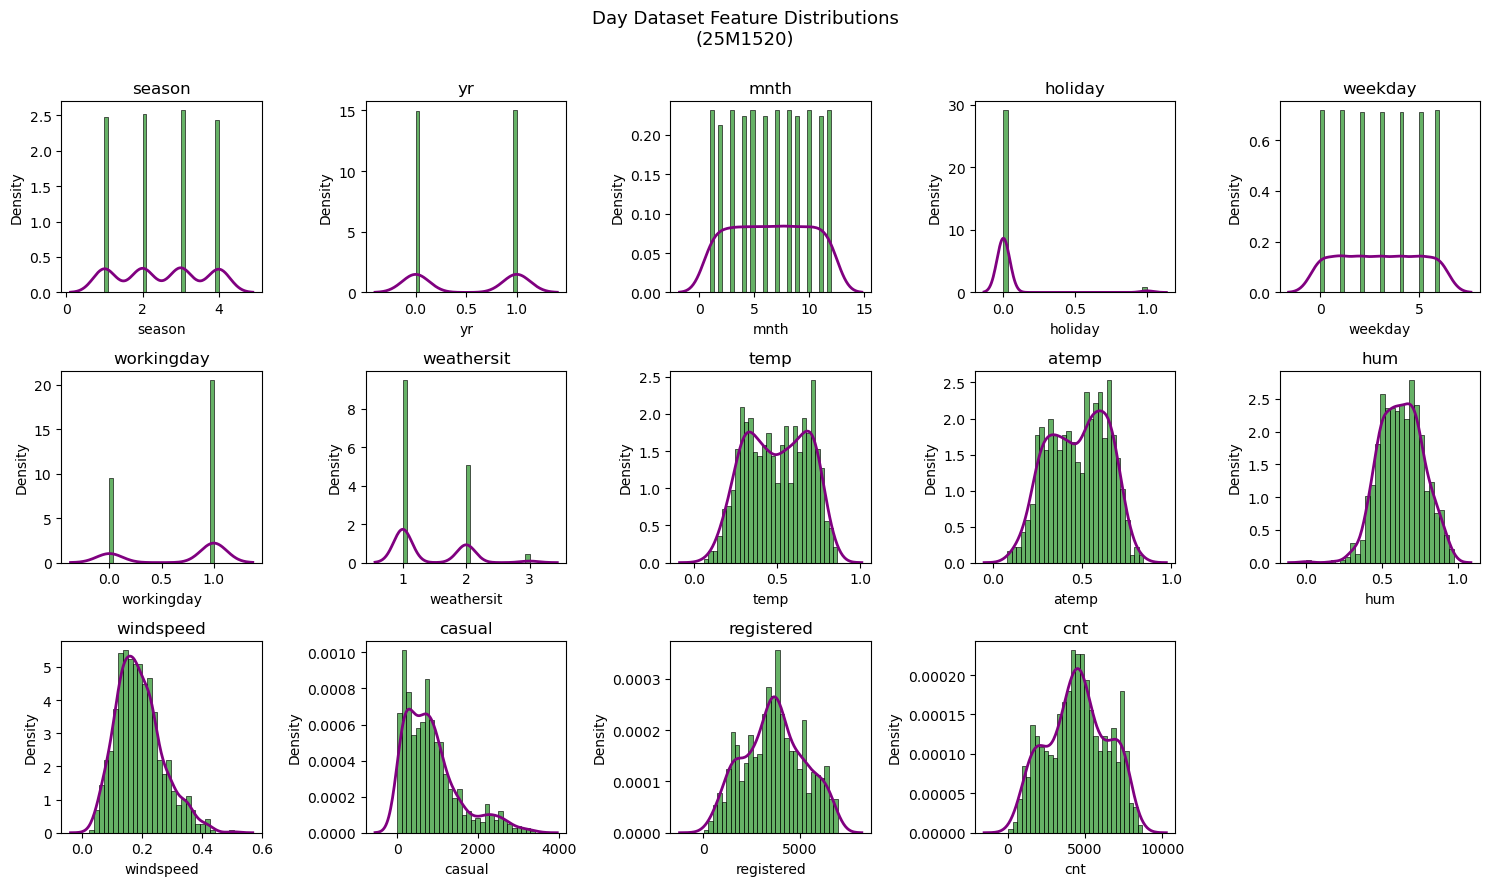

In [41]:
plot_histograms(day_df.drop(["Date"], axis=1), "Day Dataset Feature Distributions")

## {2.1.5} **Correlation** :

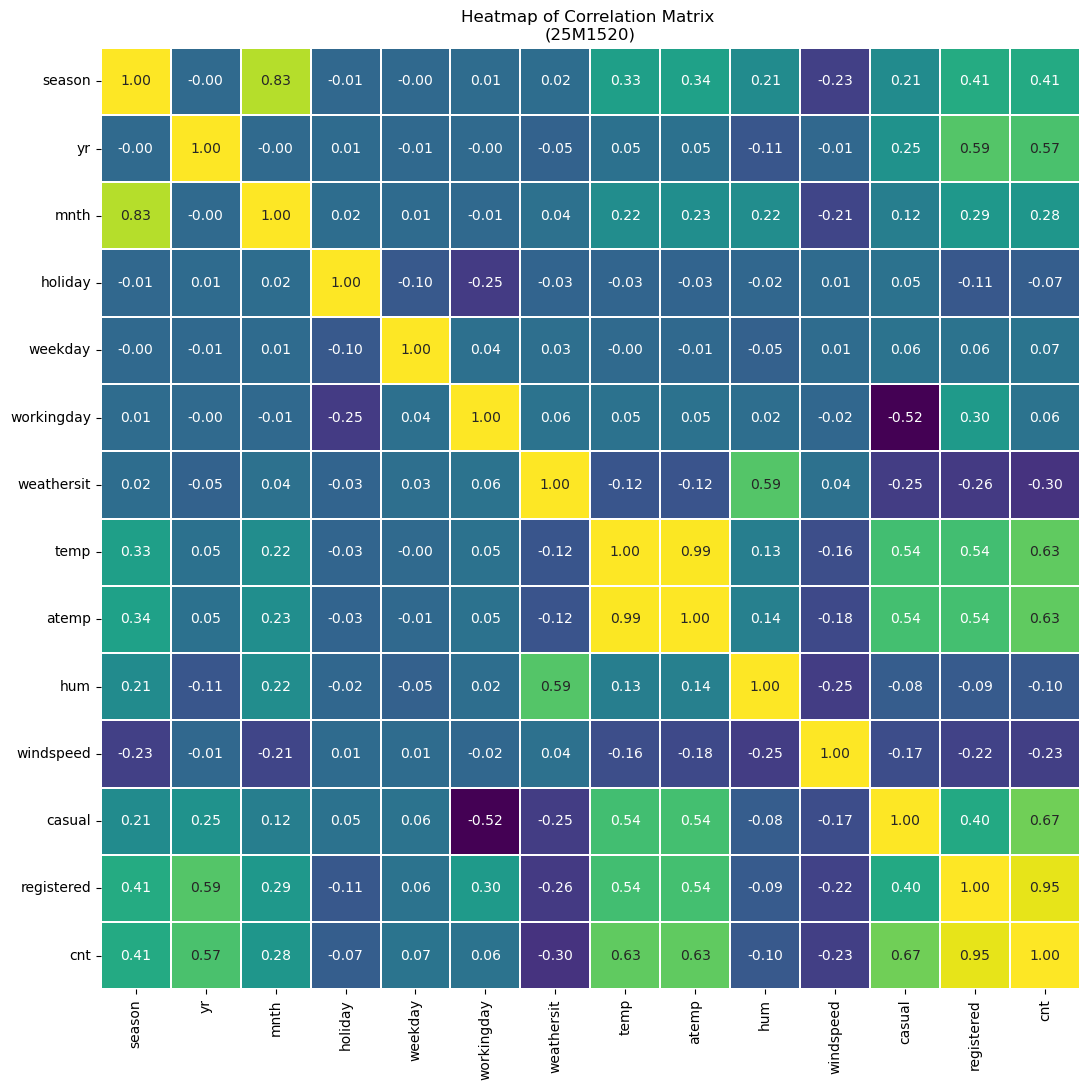

In [42]:
plt.figure(figsize=(11,11))
sns.heatmap(day_df.corr(numeric_only=True), cmap="viridis", annot=True, linewidths=0.1, fmt=".2f", cbar=False)
plt.title("Heatmap of Correlation Matrix \n(25M1520)")
plt.tight_layout()
plt.show()

## {2.1.6} **Label Distribution** :

In [43]:
X = day_df.iloc[:,:-1]
y = day_df.iloc[:,-1].values

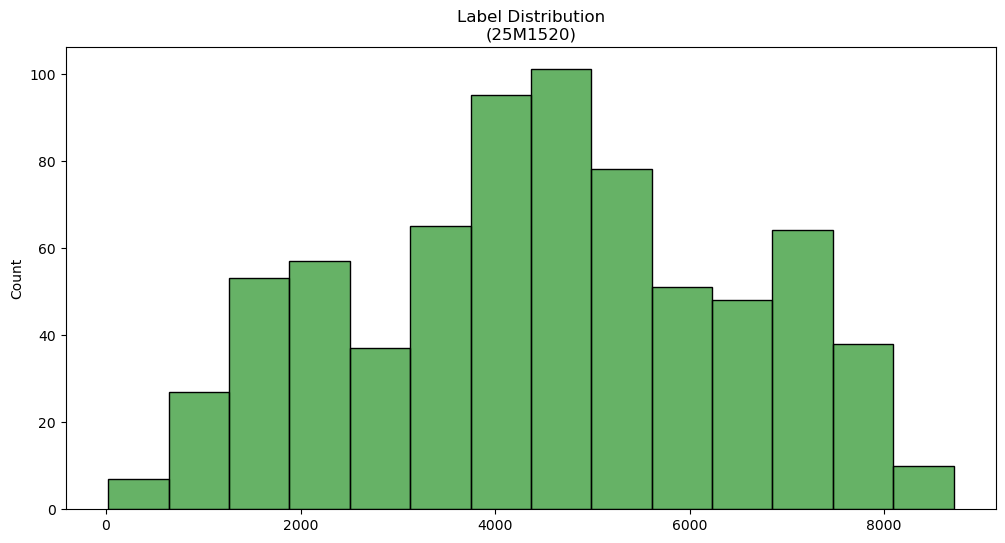

In [44]:
plt.figure(figsize=(12,6))
sns.histplot(data=y, color='green', alpha=0.6, edgecolor='black')
plt.title('Label Distribution\n(25M1520)')
plt.show()

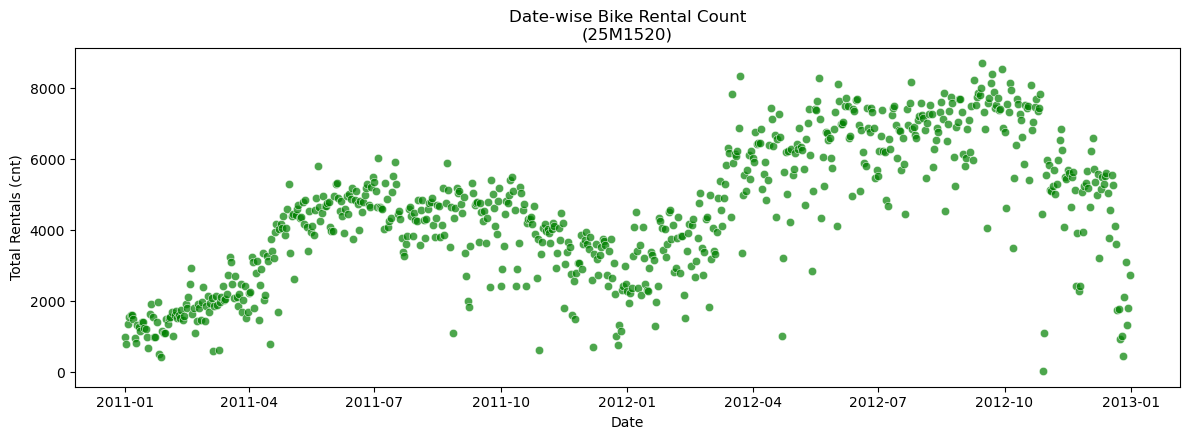

In [45]:
day_df["Date"] = pd.to_datetime(day_df["Date"])

plt.figure(figsize=(12,4.5))
sns.scatterplot(x=day_df["Date"], y=day_df["cnt"], color="green", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Total Rentals (cnt)")
plt.title("Date-wise Bike Rental Count\n(25M1520)")
plt.tight_layout()
plt.show()

Since this is a regression problem with continuous output (**cnt**), these metrics offer a concise view of our model's performance:

* **MAE (Mean Absolute Error):** Represents the average error in the actual number of rentals. It is highly intuitive and resistant to being skewed by a few extreme outliers.

* **RMSE (Root Mean Squared Error):** Measures the magnitude of error while placing a heavier penalty on large misses. It is the preferred metric when avoiding significant under- or over-estimations is critical.

* **$R^2$ Score:** Quantifies the proportion of variance in bike rentals that the model successfully explains. It serves as a primary indicator of how well the model "fits" the data.

* **Adjusted $R^2$:** Refines the $R^2$ score by accounting for the number of predictors used. It ensures that adding irrelevant variables doesn't artificially inflate the model's perceived performance.

In [46]:
corr = day_df.corr(numeric_only=True)
corr['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64

* **Very strong (but trivial) correlation:** registered and casual exhibit extremely high positive correlation with cnt, as total count is directly composed of these two variables. These should be excluded from modeling to avoid data leakage.

* **Strong positive correlation:** Temperature-related variables (temp, atemp) and time (yr) show a clear positive association with cnt. Higher temperatures and progression over years correspond to increased bike rentals.

* **Moderate positive correlation:** Seasonal factors (season) also contribute positively, indicating that certain seasons (e.g., summer/spring) see higher usage.

* **Weak or negligible correlation:** Variables like weekday and workingday have very low correlation with cnt, suggesting minimal linear impact on total rentals.

* **Negative correlation:** Weather-related variables such as weathersit, windspeed, and hum show negative associations. Poor weather conditions, higher wind speeds, and higher humidity tend to reduce bike rentals.

---

## {2.2} **Data transformations**

#### *Perform appropriate data transformations and data reduction.*

## {2.2.1} **Feature Reduction for Time-Series Analysis** :

From the documentation:
* **casual:** count of casual users
* **registered:** count of registered users
* **cnt (target):** total number of rental bikes, including both casual and registered users

$$
\text{cnt} = \text{casual} + \text{registered}
$$

Therefore, the features 'casual' and 'registered' must be dropped to prevent data leakage, as they directly contribute to the target variable. <br>
We can also see in the correlation matrix that 'registered' and 'casual' have very high correlation with target feature (**0.945517** and **0.672804** respectively)

### ***Why this is Data Leakage :***
In a real-world predictive scenario, you would not know the number of casual or registered users until after the day has ended—the same time you would know the total count. Including them as predictors would give the model information from the "future" that it wouldn't have during actual inference, leading to an over-optimistic but useless model.

In [47]:
dates = pd.to_datetime(X['Date'])   # store dates separately for further processing

# dates already contains full date info so 'yr', 'mnth', 'weekday' columns become redundant
X.drop(columns=['Date','yr', 'mnth', 'weekday', 'casual','registered'], inplace=True) 

## {2.2.2} **Feature Scaling** :

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1520)

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## {2.3} **ML model type**

#### *Compare linear regression, simple SVR, RBF kernel SVR, and decision tree, each with hyperparameter tuning. Depending on the inputs and EDA, which of these were likely to work better depending on input variables and their association with the output variable? Did the observations meet your expectations?*

## {2.3.1} **Model Building** :

In [50]:
models = {
    "Linear Regression (Elastic Net)": (
        ElasticNet(max_iter=5000),
        {
            "alpha": [0.001,0.01,0.1,1],
            "l1_ratio": [0.2,0.5,0.8],
            "fit_intercept": [True, False]
        }
    ),

    "Linear SVR": (
        LinearSVR(max_iter=5000),
        {
            "C": [0.1,1,10],
            "epsilon": [0.0,0.1,0.5]
        }
    ),

    "SVR (RBF)": (
        SVR(kernel="rbf"),
        {
            "C": [0.1,1,10],
            "gamma": [0.01,0.1,1],
            "epsilon": [0.0,0.1,0.5]
        }
    ),

    "Decision Tree": (
        DecisionTreeRegressor(),
        {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4, 10]
        }
    )
}

In [51]:
def adjusted_r2(y_true, y_pred, X):
    n, p = X.shape
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
    return adj_r2

def adj_r2_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return adjusted_r2(y, y_pred, X)

In [52]:
for name, (model, params) in models.items():
    
    grid = GridSearchCV(model, params, cv=5, scoring=adj_r2_scorer)
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print(name)
    print("Best Params:", grid.best_params_)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("Adjusted R2 Score:", adjusted_r2(y_test, y_pred, X_test_scaled))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("---"*25)

Linear Regression (Elastic Net)
Best Params: {'alpha': 0.1, 'fit_intercept': True, 'l1_ratio': 0.2}
R2 Score: 0.4625427717503916
Adjusted R2 Score: 0.4313858309822983
MAE: 1249.833641550788
RMSE: 1472.6217787323571
---------------------------------------------------------------------------
Linear SVR
Best Params: {'C': 10, 'epsilon': 0.5}
R2 Score: 0.07315546639146264
Adjusted R2 Score: 0.01942534850111266
MAE: 1527.073571828255
RMSE: 1933.8496732100948
---------------------------------------------------------------------------
SVR (RBF)
Best Params: {'C': 10, 'epsilon': 0.0, 'gamma': 0.1}
R2 Score: 0.18621905972970465
Adjusted R2 Score: 0.1390433530473687
MAE: 1505.944297075916
RMSE: 1812.0618701732942
---------------------------------------------------------------------------
Decision Tree
Best Params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 Score: 0.5126396284802174
Adjusted R2 Score: 0.48438685331965026
MAE: 1189.036311120249
RMSE: 1402.3110987780112
----

## {2.3.2} **Model Comparison** :

Four models were evaluated: **Linear Regression (Elastic Net)**, **Linear SVR**, **RBF kernel SVR** and **Decision Tree**, with hyperparameter tuning performed using cross-validation to identify the best configurations.

Overall, the models showed varying performance, with ***$R^2$ scores*** ranging from ***0.07*** to ***0.51***, indicating significant differences in their ability to capture the relationship between input features and the target variable.

### **1. Linear Regression (Elastic Net):**
Achieved an ***$R^2$ score*** of ***0.463*** with relatively lower error values (***RMSE: 1472, MAE: 1249***). This suggests that there is a **moderate linear relationship** between the features and the target. The use of Elastic Net regularization helped balance bias and variance while handling multicollinearity.

### **2. Linear SVR:**
Performed poorly, with an ***$R^2$ score*** of ***0.070*** and the highest error values (***RMSE: 1936, MAE: 1529***). This indicates that a strictly linear margin-based approach is not suitable for this dataset, likely due to its inability to capture more complex relationships.

### **3. RBF kernel SVR:**
Improved upon Linear SVR, achieving an ***$R^2$ score*** of ***0.186*** with reduced errors (***RMSE: 1812, MAE: 1505***). This suggests the presence of non-linear patterns in the data. However, the improvement is still limited, indicating that SVR models may struggle to fully capture the underlying structure.

### **4. Decision Tree:**
Performed the best, with the ***highest $R^2$ score*** of ***0.513*** and the ***lowest error values*** (***RMSE: 1402, MAE: 1189***). This indicates that the data likely contains non-linear relationships and threshold-based patterns, which are effectively captured by tree-based models.

## {2.3.3} **Conclusion** :

**Yes**, the model results are consistent with the patterns observed in the EDA.

* The **Decision Tree** outperforming all models suggests the presence of ***nonlinear*** and ***interaction effects*** among features, which are not captured by linear models.

* Moderate linear relationships between input variables and `cnt` explain why **Elastic Net** performs well, achieving ***reasonably high $R^2$*** and ***Adjusted $R^2$*** compared to other linear models.

* The relatively low performance of **RBF SVR** shows that although non-linearities exist, they are ***not smooth or continuous***, but rather ***piecewise***, favoring tree-based models.

* The very poor performance of **Linear SVR** indicates that a ***strict linear margin-based approach*** is not suitable for this dataset.

* Features with weaker correlations contribute less to prediction, which explains the ***overall moderate performance*** across models.

* The error metrics (***MAE and RMSE***) further confirm that ***Decision Tree provides the most accurate predictions***, followed by Elastic Net.

Overall, while **linear relationships are present**, the dataset is better explained by **nonlinear**, **rule-based patterns**, which is why the **Decision Tree** achieves the best performance, while SVR models underperform.

---

## {2.4} **Appropriateness of splits** 

#### *A useful model for temporal prediction should give good performance on future data when trained on past data. Instead of random train-val-test splits, if these splits were temporally ordered (e.g. past, present, future), then how does it affect the performance?*

In [53]:
day_df

,Date,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


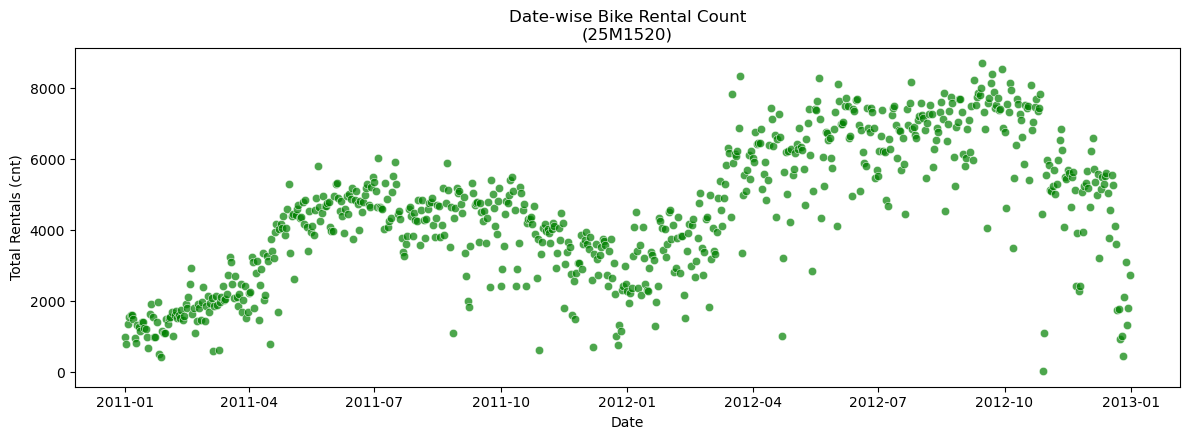

In [54]:
plt.figure(figsize=(12,4.5))
sns.scatterplot(x=day_df["Date"], y=day_df["cnt"], color="green", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Total Rentals (cnt)")
plt.title("Date-wise Bike Rental Count\n(25M1520)")
plt.tight_layout()
plt.show()

The dataset exhibits a clear temporal pattern with trends and seasonal variations across 2011 and 2012. Therefore, using a random train-test split is inappropriate, as it mixes past and future data, leading to overly optimistic performance due to data leakage.

A more suitable approach is a time-based split, where the model is trained on 2011 data and tested on 2012 data. This ensures that predictions are made on unseen future data, reflecting real-world deployment.

In [55]:
df = day_df.sort_values("Date")   # ensure sorted

train = df[df["yr"] == 0]   # 2011
test  = df[df["yr"] == 1]   # 2012

train.drop(columns=['Date','yr', 'mnth', 'weekday', 'casual', 'registered'], inplace=True) 
test.drop(columns=['Date','yr', 'mnth', 'weekday','casual', 'registered'], inplace=True)

X_train = train.iloc[:,:-1]
y_train = train.iloc[:,-1]

X_test = test.iloc[:,:-1]
y_test = test.iloc[:,-1]

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
for name, (model, params) in models.items():
    
    grid = GridSearchCV(model, params, cv=5, scoring=adj_r2_scorer)
    grid.fit(X_train_scaled, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print(name)
    print("Best Params:", grid.best_params_)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("Adjusted R2 Score:", adjusted_r2(y_test, y_pred, X_test_scaled))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("---"*25)

Linear Regression (Elastic Net)
Best Params: {'alpha': 0.01, 'fit_intercept': True, 'l1_ratio': 0.2}
R2 Score: -0.7007551997028765
Adjusted R2 Score: -0.7388673610407561
MAE: 2127.6172688528713
RMSE: 2329.466656663156
---------------------------------------------------------------------------
Linear SVR
Best Params: {'C': 10, 'epsilon': 0.5}
R2 Score: -1.9219130513795744
Adjusted R2 Score: -1.9873900945477443
MAE: 2846.9091414670497
RMSE: 3053.2983210819884
---------------------------------------------------------------------------
SVR (RBF)
Best Params: {'C': 10, 'epsilon': 0.0, 'gamma': 0.1}
R2 Score: -0.9379479460987796
Adjusted R2 Score: -0.981375351053374
MAE: 2197.608957113937
RMSE: 2486.604118073368
---------------------------------------------------------------------------
Decision Tree
Best Params: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5}
R2 Score: -0.6898911186743375
Adjusted R2 Score: -0.7277598272160593
MAE: 2109.67189567735
RMSE: 2322.014655652597
--

A comparison was conducted using temporally ordered splits (training on past data and testing on future data) instead of random splits to evaluate the models’ ability to generalize over time.

Across all models—Linear Regression (Elastic Net), Linear SVR, RBF SVR, and Decision Tree—there is a significant drop in performance, with all models yielding negative R² scores. This indicates that the models perform worse than a simple mean predictor when applied to future data.

**Linear Regression (Elastic Net)** achieved an ***R² score*** of ***-0.70***, with ***high error values*** (***RMSE: 2329, MAE: 2127***). This suggests that the linear relationships learned from past data do not hold consistently over time, indicating possible non-stationarity in the data.

**Linear SVR** performed the worst, with an ***R² score*** of ***-1.92*** and the ***highest errors*** (***RMSE: 3051, MAE: 2845***). This highlights that a linear margin-based approach is highly sensitive to distribution shifts and fails to generalize to future data.

**RBF SVR** showed some improvement over **Linear SVR** but still performed poorly, with an ***R² score*** of ***-0.94***. Although it captures non-linear patterns, it is still unable to adapt to temporal changes, suggesting that the learned non-linear relationships are not stable over time.

The **Decision Tree**, which previously performed best under random splits, also experienced a sharp decline, with an ***R² score*** of ***-0.72***. This indicates that the tree likely overfits patterns specific to the training period and fails to generalize when those patterns shift in the future.

---

## {2.5} **Feature importance**

#### *Find the relative importance of each feature using at least two techniques to determine feature importance (e.g., permutation, accuracy drop upon removal).*

In [58]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [59]:
best_model = DecisionTreeRegressor(max_depth=3, min_samples_leaf=1, min_samples_split=2)
best_model.fit(X_train_scaled, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## {2.5.1} **Permutation Importance** :

In [60]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=1520,
    scoring=adj_r2_scorer
)

perm_importance = pd.Series(perm.importances_mean, index=X_test_scaled.columns)
perm_importance = perm_importance.sort_values(ascending=False)

print("Permutation Importance:")
print(perm_importance)

Permutation Importance:
temp          0.319796
weathersit    0.092919
season        0.068509
holiday       0.000000
workingday    0.000000
windspeed     0.000000
hum          -0.005238
atemp        -0.096062
dtype: float64


Permutation importance measures the increase in error when a feature’s values are randomly shuffled, thereby breaking its relationship with the target.

* Most important feature: `temp (0.320)`, indicating that temperature remains the dominant driver of the target variable.

* Other relevant features include `weathersit (0.093)` and `season (0.069)`, suggesting environmental and seasonal effects are important.

* Features such as `holiday`, `workingday` and `windspeed` show zero importance, meaning the model does not rely on them.

* `hum (-0.005)` and `atemp (-0.096)` have negative importance, indicating redundancy or noise, with `atemp` likely overlapping strongly with temp.

## {2.5.2} **Accuracy Drop Upon Removal** :

In [61]:
baseline = adjusted_r2(y_test, best_model.predict(X_test_scaled), X_test_scaled)

drop_importance = {}

for col in X_test_scaled.columns:
    X_train_drop = X_train_scaled.drop(columns=[col])
    X_test_drop = X_test_scaled.drop(columns=[col])
    
    temp_model = ElasticNet(alpha=0.001, l1_ratio=0.8, fit_intercept=True)
    temp_model.fit(X_train_drop, y_train)
    
    new_score = adjusted_r2(y_test, temp_model.predict(X_test_drop), X_test_drop)
    
    drop_importance[col] = baseline - new_score  # drop in performance

drop_importance = pd.Series(drop_importance).sort_values(ascending=False)

print("Accuracy Drop Importance:")
print(drop_importance)

Accuracy Drop Importance:
season        0.036949
windspeed     0.002367
hum          -0.000431
holiday      -0.023599
workingday   -0.026538
temp         -0.027072
atemp        -0.027152
weathersit   -0.034447
dtype: float64


This method evaluates the decrease in model performance when each feature is removed.

* Most important feature: `season (0.037)`, followed by a small contribution from `windspeed (0.002)`.

* All other features, including `temp (-0.027)` and `weathersit (-0.034)`, show negative importance, meaning their removal does not harm (and may slightly improve) performance.

* `holiday` and `workingday` again appear uninformative or slightly detrimental.

## **Verdict** :

Both methods agree that:
* `Seasonal effects (season)` are consistently important

* `holiday` and `workingday` contribute very little

However, there is a strong disagreement:
* **Permutation Importance** identifies `temp` as the most **critical feature**

* **Accuracy Drop** suggests `temp` is **redundant or replaceable**

This discrepancy is a clear indication of **multicollinearity**, especially between `temp` and `atemp`, and possibly overlap with `season` and `weathersit`.

---

# **(3) Wine Quality**

#### *Predict wine quality from physicochemical measurements. You will examine how the same dataset behaves under different learning formulations.*

In [62]:
white_df = pd.read_csv("winequality-white.csv", sep=";")
white_df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7
4897,6.0,0.21,0.38,0.8,0.020,22.0,98.0,0.98941,3.26,0.32,11.8,6


In [63]:
red_df = pd.read_csv("winequality-red.csv", sep=";")
red_df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [64]:
white_df["quality"].value_counts().sort_index()

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

In [65]:
red_df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

---

## {3.1} **Explore the data** 

#### *Note down your observations about the problem type, variable types, missing variables, distributions, correlations, and label distribution. Are there any strong associations between any input and output variable that are immediately obvious? What performance metrics should be used and why?*

## {3.1.1} **Problem Type** :

These datasets can be viewed as **classification** or **regression** tasks. <br>
The classes are **ordered** and not **balanced** (e.g. there are many more normal wines than excellent or poor ones).

## {3.1.1} **Variable Types** :

In [66]:
white_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [67]:
red_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


All input features are **numerical** (**continuous**):

Output variable (**quality**) is **Discrete ordinal integer** (typically 3–9)

## {3.1.3} **Missing Variables** :

In [68]:
white_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [69]:
red_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**The datasets have no missing values.**

In [70]:
white_df.duplicated().sum()

np.int64(937)

In [71]:
red_df.duplicated().sum()

np.int64(240)

### ***Remove Duplicate Samples :***

The dataset contains duplicate records:

* **White wine dataset**: 937 duplicate samples
* **Red wine dataset**: 240 duplicate samples

This indicates **data redundancy**, which can:

* **Bias the model toward repeated patterns**
* **Inflate performance metrics** if duplicates appear in both train and test sets

In [72]:
# Keep only the first occurrence, remove all other duplicates
white_df = white_df.drop_duplicates(keep='first')
white_df.shape

(3961, 12)

In [73]:
# Keep only the first occurrence, remove all other duplicates
red_df = red_df.drop_duplicates(keep='first')
red_df.shape

(1359, 12)

## {3.1.4} **Distribution** :

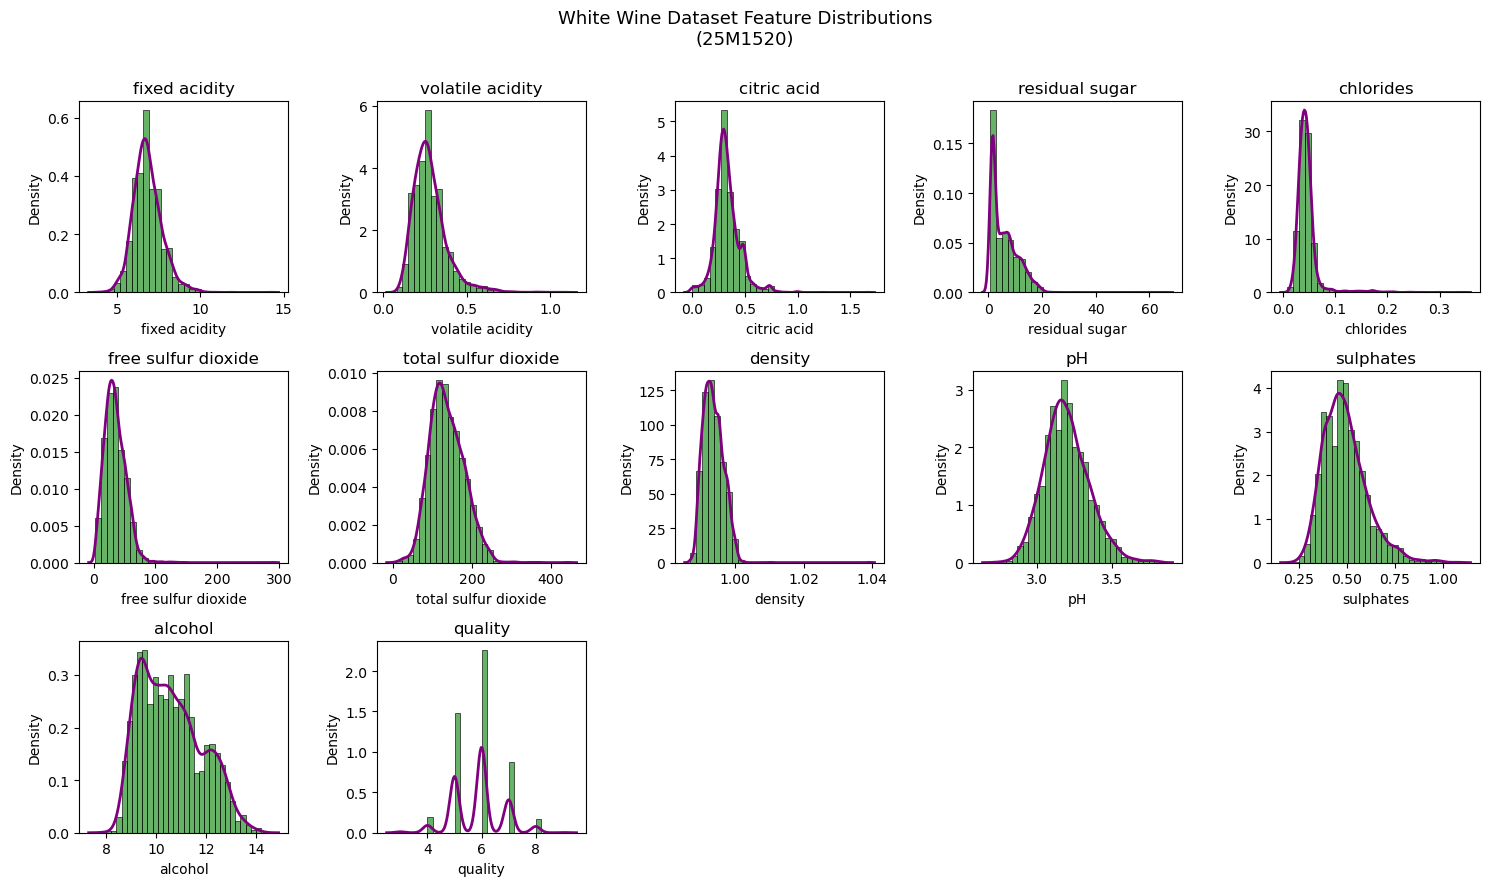

In [74]:
plot_histograms(white_df, "White Wine Dataset Feature Distributions")

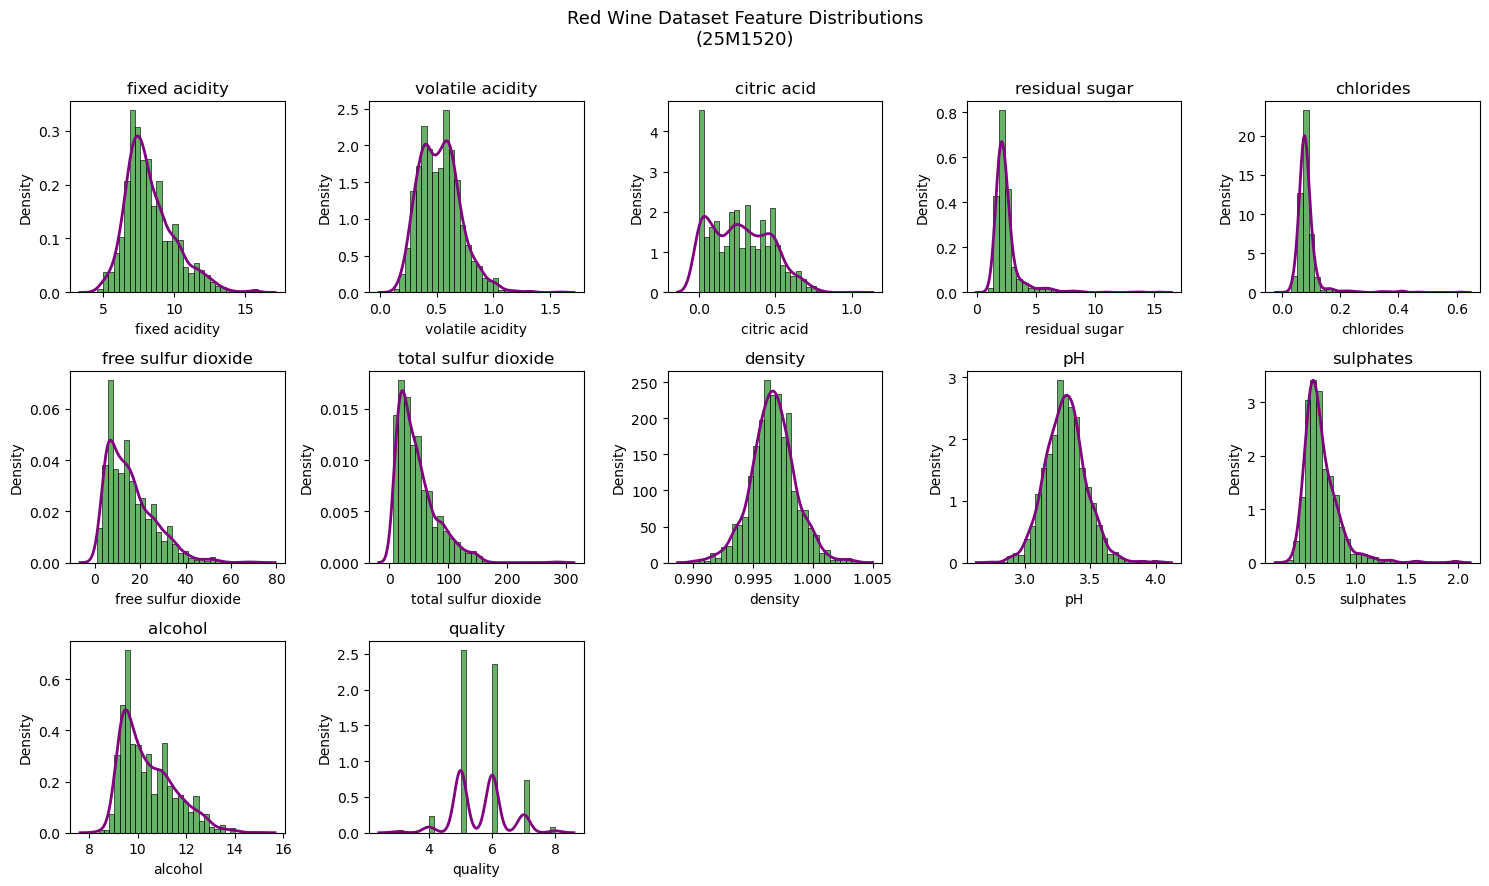

In [75]:
plot_histograms(red_df, "Red Wine Dataset Feature Distributions")

## {3.1.5} **Correlation** :

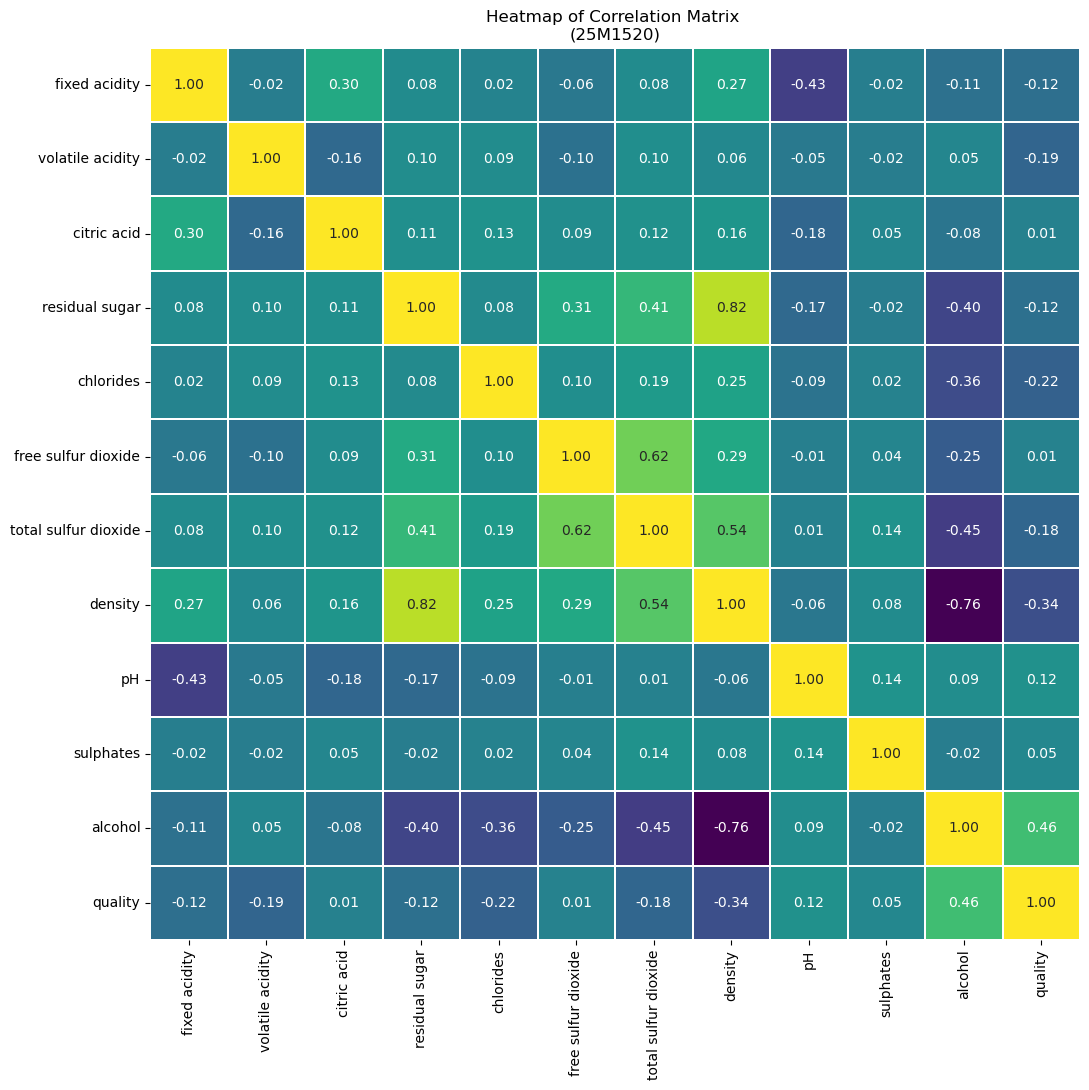

In [76]:
plt.figure(figsize=(11,11))
sns.heatmap(white_df.corr(), cmap="viridis", annot=True, linewidths=0.1, fmt=".2f", cbar=False)
plt.title("Heatmap of Correlation Matrix \n(25M1520)")
plt.tight_layout()
plt.show()

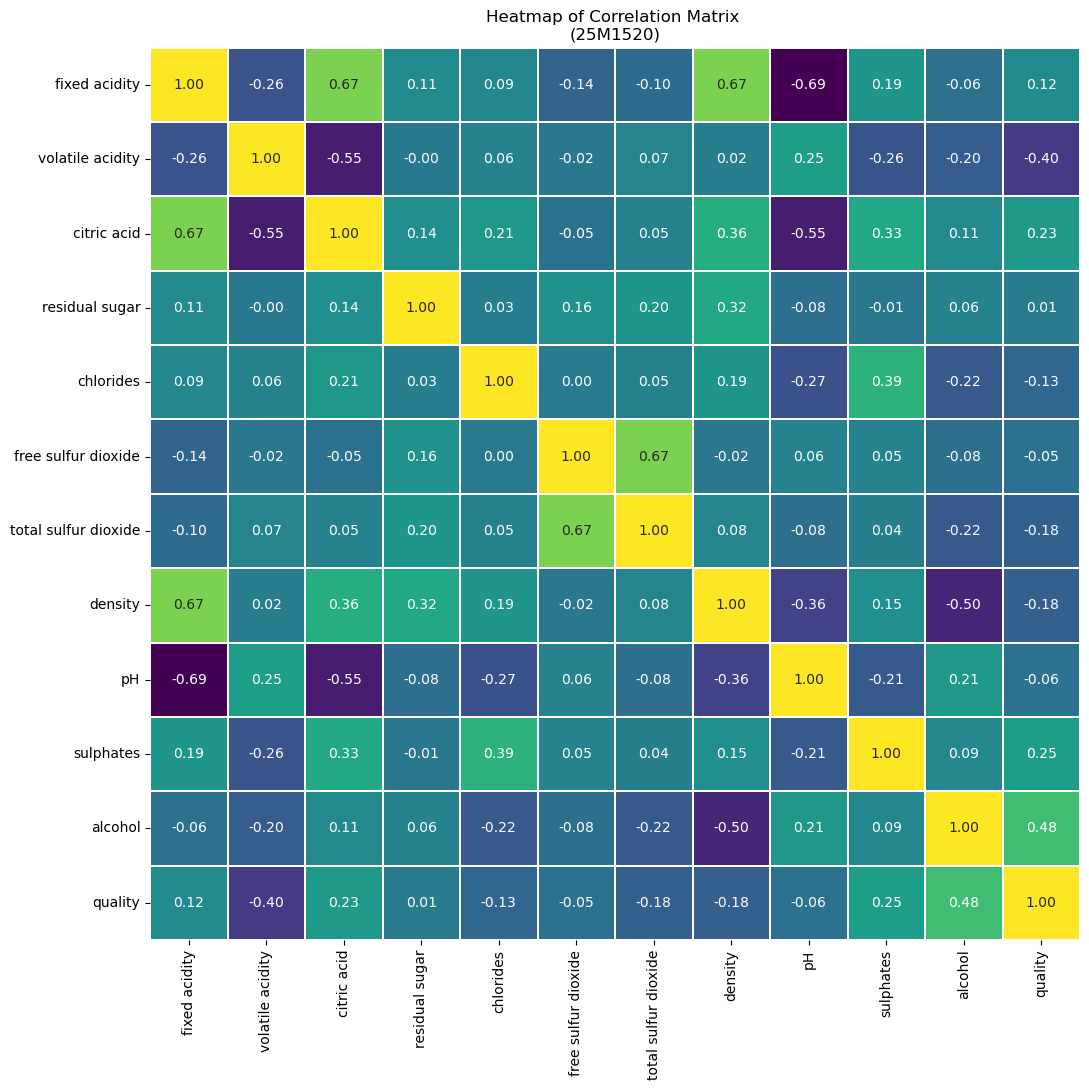

In [77]:
plt.figure(figsize=(11,11))
sns.heatmap(red_df.corr(), cmap="viridis", annot=True, linewidths=0.1, fmt=".2f", cbar=False)
plt.title("Heatmap of Correlation Matrix \n(25M1520)")
plt.tight_layout()
plt.show()

## {3.1.6} **Label Distribution** :

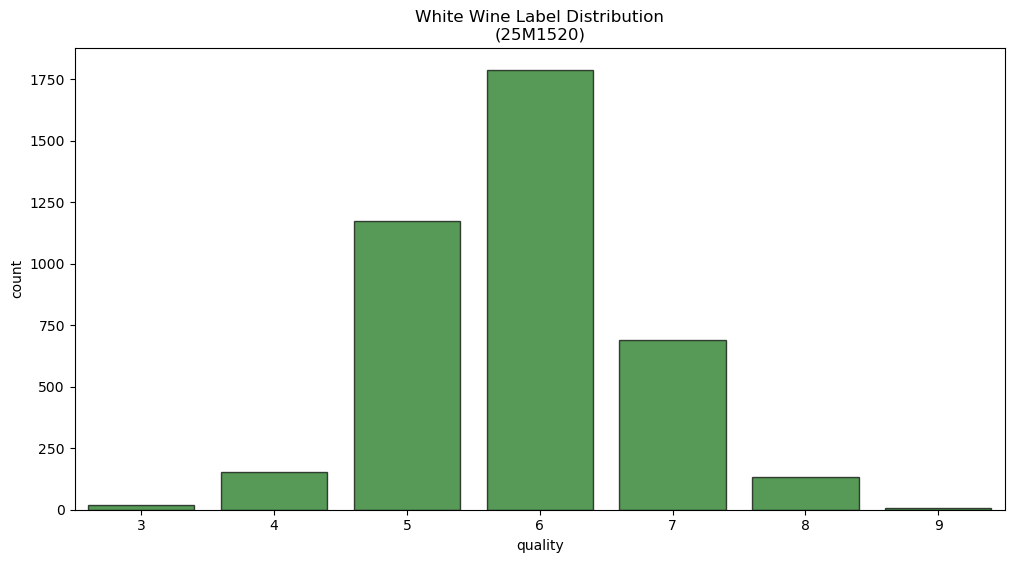

In [78]:
plt.figure(figsize=(12,6))
sns.countplot(x=white_df["quality"], color='green', alpha=0.7, edgecolor='black')
plt.title('White Wine Label Distribution\n(25M1520)')
plt.show()

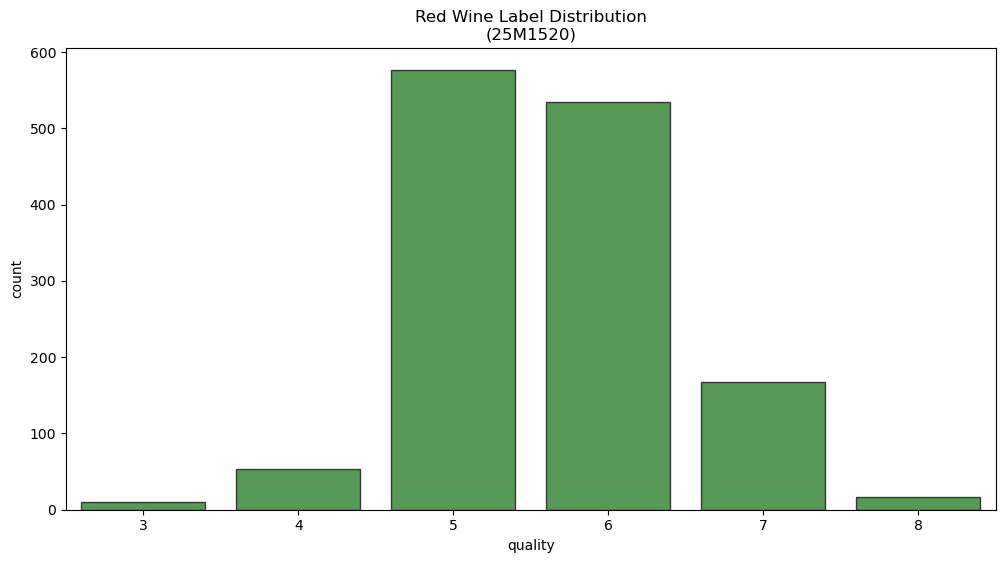

In [79]:
plt.figure(figsize=(12,6))
sns.countplot(x=red_df["quality"], color='green', alpha=0.7, edgecolor='black')
plt.title('Red Wine Label Distribution\n(25M1520)')
plt.show()

---

## {3.2} **Data transformations**

#### *Perform appropriate data transformations and data reduction.*

In [80]:
X_white = white_df.iloc[:,:-1]
y_white = white_df.iloc[:,-1]

X_red = red_df.iloc[:,:-1]
y_red = red_df.iloc[:,-1]

In [81]:
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_white, y_white, test_size=0.2, random_state=1520)
X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_red, y_red, test_size=0.2, random_state=1520)

## {3.2.1} **Feature Scaling** :

In [82]:
scaler_w = StandardScaler()
X_w_train_scaled = pd.DataFrame(scaler_w.fit_transform(X_w_train), columns=X_w_train.columns)
X_w_test_scaled = pd.DataFrame(scaler_w.transform(X_w_test), columns=X_w_test.columns)

scaler_r = StandardScaler()
X_r_train_scaled = pd.DataFrame(scaler_r.fit_transform(X_r_train), columns=X_r_train.columns)
X_r_test_scaled = pd.DataFrame(scaler_r.transform(X_r_test), columns=X_r_test.columns)

## {3.2.2} **Feature Reduction** :

**For both datasets feature reduction is unnecessary.**

---

## {3.3} **Problem formulation**

#### *Compare regression, classification, and ordinal regression (advanced, e.g. will need ranking loss) formulations for a neural network model with a single hidden layer. What are your practical insights about which of these problem formulations leads to usable predictions. Do this separately for white and red wine.*

In this study, the wine quality prediction problem is formulated in three different ways: regression, classification, and ordinal regression. Each formulation captures a different interpretation of the target variable (wine quality score), and a neural network with a single hidden layer is trained under each setting.

### ***1. Regression Formulation :***
In the regression setting, wine quality is treated as a continuous variable.


**Let:** 
* $x \in \mathbb{R}^d$ be the input features 
* $y \in \mathbb{R}$ be the quality score
The neural network learns a function:
$$ 
f(x; \theta) = \hat{y}
$$
where $\theta$ represents the model parameters.The model is trained by minimizing the **Mean Squared Error (MSE):**
$$
\mathcal{L}_{reg} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

**Insight:**
* **Captures magnitude of error:** The loss is directly proportional to how far the prediction is from the actual value.

* **Penalizes large deviations strongly:** Due to the squaring of the error $(y_i - \hat{y}_i)^2$, outliers or large misses result in a much higher penalty than small ones.

* **Does not explicitly consider ordering between classes:** While it treats the output as a scale, it doesn't view the quality scores as discrete ordered categories (like "Good" vs. "Better"), but rather as points on a mathematical line.

### ***2. Classification Formulation :***
In this formulation, wine quality is treated as a categorical variable with discrete classes (e.g., 3–8). 
* **Let:**   $y \in \{1, 2, \dots, K\}$ represent the set of possible quality labels. 
* **Model Output:** The neural network outputs class probabilities using the softmax function:
$$
P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$
* **Optimization:** The model is trained by minimizing the Cross-Entropy Loss:
$$
\mathcal{L}_{cls} = -\sum_{i=1}^{N} \sum_{k=1}^{K} \mathbb{1}(y_i = k) \log P(y_i = k \mid x_i)
$$

**Insight:**
* **Treats all classes as independent:** The model sees "Grade 3" and "Grade 4" as distinct labels without any inherent mathematical relationship or proximity.

* **Uniform Penalty:** Misclassifying a "Grade 3" wine as "Grade 4" is penalized exactly the same as misclassifying it as "Grade 8." The loss function only cares if the prediction is "not correct".

* **Ignores Spectrum:** It loses the crucial information that wine quality exists on a continuous spectrum of "better" or "worse."

### ***3. Ordinal Regression Formulation:*** 
Wine quality is inherently **ordered**, making ordinal regression a more suitable approach than standard classification.
* **Prediction Strategy:** Instead of predicting a single discrete label, the model predicts the probability of the quality exceeding specific thresholds:
$$
P(y > k \mid x), \quad k = 1, 2, \dots, K-1
$$

* **Binary Decomposition:** This converts the multi-class problem into $K-1$ **binary classification tasks** (e.g., "Is the quality > 3?", "Is it > 4?", etc.).

* **Loss Function:** The loss is typically the sum of **Binary Cross-Entropy (BCE)** across all thresholds:
$$
\mathcal{L}_{ord} = \sum_{k=1}^{K-1} \text{BCE}(y > k, \hat{P}(y > k))
$$

**Insight:**
* **Preserves ordering information:** The model architecture respects the hierarchy (e.g., to be a "Grade 6," the wine must satisfy the conditions for being "greater than 5").

* **Distance-Aware Penalty:** It penalizes larger errors more naturally; a prediction that misses multiple thresholds will accumulate a much higher loss than one that just misses the adjacent threshold.

* **Human-Centric:** Better reflects real-world ranking and rating systems where the difference between "Average" and "Excellent" is a matter of degree rather than a completely different category.

In [83]:
def to_tensor(X, y, y_dtype=torch.long):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        X = X.to_numpy()
    if isinstance(y, (pd.DataFrame, pd.Series)):
        y = y.to_numpy()
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=y_dtype)

def create_loader(X, y, batch=32, shuffle=True):
    return DataLoader(TensorDataset(X, y), batch_size=batch, shuffle=shuffle)

In [84]:
class RegressionNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

class ClassificationNN(nn.Module):
    def __init__(self, d, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, c)
        )
    def forward(self, x): return self.net(x)

In [85]:
def regression(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other, epochs=100):
    y_tr = y_tr.float().view(-1,1)

    train_loader = create_loader(X_tr, y_tr)

    model = RegressionNN(X_tr.shape[1])
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    with torch.no_grad():
        pred_te = model(X_te).numpy().flatten()
        pred_other = model(torch.tensor(scaler.transform(X_other), dtype=torch.float32)).numpy().flatten()

    y_other_np = y_other.to_numpy() if isinstance(y_other, pd.Series) else y_other.numpy()

    return {
        "In RMSE": np.sqrt(mean_squared_error(y_te.numpy(), pred_te)),
        "Cross RMSE": np.sqrt(mean_squared_error(y_other_np, pred_other))
    }

In [86]:
def classification(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other, epochs=100):

    if not isinstance(y_other, torch.Tensor):
        y_other = torch.tensor(y_other.to_numpy(), dtype=torch.float32)

    y_tr = torch.round(y_tr).long()
    y_te = torch.round(y_te).long()
    y_other = torch.round(y_other).long()

    y_tr -= y_tr.min()
    y_te -= y_te.min()
    y_other -= y_other.min()

    num_classes = int(y_tr.max()+1)

    train_loader = create_loader(X_tr, y_tr)

    model = ClassificationNN(X_tr.shape[1], num_classes)
    opt = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    with torch.no_grad():
        pred_te = model(X_te).argmax(1).numpy()
        pred_other = model(torch.tensor(scaler.transform(X_other), dtype=torch.float32)).argmax(1).numpy()

    return {
        "In Acc": accuracy_score(y_te.numpy(), pred_te),
        "Cross Acc": accuracy_score(y_other.numpy(), pred_other)
    }

In [87]:
def ordinal(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other):

    if not isinstance(y_other, torch.Tensor):
        y_other = torch.tensor(y_other.to_numpy(), dtype=torch.float32)

    y_tr = torch.round(y_tr).long()
    y_te = torch.round(y_te).long()
    y_other = torch.round(y_other).long()

    y_tr -= y_tr.min()
    y_te -= y_te.min()
    y_other -= y_other.min()

    model = LogisticIT()
    model.fit(X_tr.numpy(), y_tr.numpy())

    pred_te = model.predict(X_te.numpy())
    pred_other = model.predict(scaler.transform(X_other))

    return {
        "In Acc": accuracy_score(y_te.numpy(), pred_te),
        "Cross Acc": accuracy_score(y_other.numpy(), pred_other)
    }

---

## {3.4} **Distribution shift**

#### *Do you expect a model trained on red wine data alone to work well when tested on white wine, and vice versa? Confirm this. What are your observations about the overlap in the distributions of the two datasets?*

In [88]:
torch.manual_seed(1520)

is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print(f"using device : {device}")

using device : cpu


In [89]:
X_w_tr_t, y_w_tr_t = to_tensor(X_w_train_scaled, y_w_train)
X_w_te_t, y_w_te_t = to_tensor(X_w_test_scaled, y_w_test)

X_r_tr_t, y_r_tr_t = to_tensor(X_r_train_scaled, y_r_train)
X_r_te_t, y_r_te_t = to_tensor(X_r_test_scaled, y_r_test)

In [90]:
def run_all(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other):
    return {
        "Regression": regression(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other),
        "Classification": classification(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other),
        "Ordinal": ordinal(X_tr, X_te, y_tr, y_te, scaler, X_other, y_other)
    }

In [91]:
def format_results(title, results):
    print(f"\n{title}")
    print("-" * 55)
    print(f"{'Task':<22}{'In-domain':<15}{'Cross-domain':<15}")
    print("-" * 55)

    print(f"{'Regression (RMSE)':<22}"
          f"{results['Regression']['In RMSE']:<15.3f}"
          f"{results['Regression']['Cross RMSE']:<15.3f}")

    print(f"{'Classification (Acc)':<22}"
          f"{results['Classification']['In Acc']*100:<15.2f}"
          f"{results['Classification']['Cross Acc']*100:<15.2f}")

    print(f"{'Ordinal (Acc)':<22}"
          f"{results['Ordinal']['In Acc']*100:<15.2f}"
          f"{results['Ordinal']['Cross Acc']*100:<15.2f}")

    print("-" * 55)

# Run experiments (train on RED, test on WHITE)

In [92]:
res_rw = run_all(X_r_tr_t, X_r_te_t, y_r_tr_t, y_r_te_t, scaler_r, X_w_test, y_w_test)
format_results("🔴 Red --> White", res_rw)


🔴 Red --> White
-------------------------------------------------------
Task                  In-domain      Cross-domain   
-------------------------------------------------------
Regression (RMSE)     0.675          1.099          
Classification (Acc)  52.94          39.09          
Ordinal (Acc)         56.25          48.55          
-------------------------------------------------------


# Run experiments (train on WHITE, test on RED)

In [93]:
res_wr = run_all(X_w_tr_t, X_w_te_t, y_w_tr_t, y_w_te_t, scaler_w, X_r_test, y_r_test)
format_results("⚪ White --> Red", res_wr)


⚪ White --> Red
-------------------------------------------------------
Task                  In-domain      Cross-domain   
-------------------------------------------------------
Regression (RMSE)     0.742          1.396          
Classification (Acc)  53.59          14.71          
Ordinal (Acc)         52.46          45.59          
-------------------------------------------------------


### ***Cross-Domain Generalization Analysis :***

Models trained on one wine type (red or white) are not expected to perform well when tested on the other. This is confirmed by the results, which show a consistent drop in performance in cross-domain settings for all three formulations.

**Performance Degradation :**<br><br>
**Red $\rightarrow$ White:** 
- RMSE increases from ***0.675*** to ***1.099***.
- Classification Accuracy drops from ***54.78%*** to ***41.11%***.
- Ordinal Accuracy drops from ***56.25%*** to ***48.55%***.


**White $\rightarrow$ Red:**
The degradation is even more severe:
- RMSE increases from ***0.742*** to ***1.397***.
- Classification Accuracy drops drastically from ***52.59%*** to ***20.22%***.
- Ordinal Accuracy drops from ***52.46%*** to ***45.59%***.

### ***Key Reasons for Poor Generalization :***
* **Distributional Differences:** The feature distributions (such as acidity, alcohol content, and sulphates) differ significantly between red and white wines.

* **Feature-Label Relationship:** The relationship between input features and quality scores varies across the two datasets. Patterns learned on one dataset do not transfer effectively to the other.

* **Partial Feature Space Overlap:** There is only a partial overlap in feature space, and the mapping from features to quality labels is inconsistent. This leads to a mismatch in learned decision boundaries.

### ***Conclusion on Robustness :***
Among the formulations, **ordinal regression** demonstrates relatively better robustness. It leverages the ordered nature of quality labels, whereas classification suffers the most due to its inability to account for ordinal relationships.

---

In [94]:
end = time.time()

In [95]:
duration = end - start
m = int(duration//60)
s = duration % 60

print(f"Total Execution Time: {m}m {s:.1f}s")

Total Execution Time: 16m 38.8s


---